In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"
# Pin these two exactly — this is the version combo known to work cleanly with
# Unsloth's gradient checkpointing on T4/P100 (avoids the bf16/GradScaler bug
# and the newer-trl API changes like tokenizer->processing_class).
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install wandb


In [3]:
from datasets import load_dataset

train=load_dataset("HuggingFaceH4/CodeAlpaca_20K",split="train")

README.md:   0%|          | 0.00/195 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/756 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.01M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/336k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18019 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2003 [00:00<?, ? examples/s]

In [4]:
train[0]

{'prompt': 'Create a Java class which sorts the given array of numbers.\n[9, 2, 4, 3, 6, 1]',
 'completion': 'class ArraySort { \n  \n    void sort(int arr[]) { \n        int n = arr.length; \n  \n        // One by one move boundary of unsorted subarray \n        for (int i = 0; i < n-1; i++) { \n            \n            // Find the minimum element in unsorted array \n            int min_index = i; \n            for (int j = i+1; j < n; j++) \n                if (arr[j] < arr[min_index]) \n                    min_index = j; \n  \n            // Swap the found minimum element with the first element \n            int temp = arr[min_index]; \n            arr[min_index] = arr[i]; \n            arr[i] = temp; \n        } \n    } \n  \n    // Prints the array \n    void printArray(int arr[]) { \n        int n = arr.length; \n        for (int i=0; i<n; ++i) \n            System.out.print(arr[i] + " "); \n        System.out.println(); \n    } \n  \n    // Driver code to test above \n    publi

In [5]:
test=load_dataset("HuggingFaceH4/CodeAlpaca_20K",split="test[:500]")

In [6]:
test[0]

{'prompt': 'Design a class for representing a person in Python.\n',
 'completion': 'class Person:\n    """\n    Class to represent a person\n    """\n    def __init__(self, name, age, address):\n        self.name = name\n        self.age = age\n        self.address = address\n    \n    def birthday(self):\n        """\n        Increments the age of the person\n        """\n        self.age += 1'}

In [7]:
from unsloth import FastLanguageModel
model,tokenizer=FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen3-0.6B",
    load_in_4bit=True,
    max_seq_length=2048,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/576M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [8]:
def change_to_alpaca(examples):
    prompt=examples["prompt"]
    completion=examples["completion"]
    conversations=[
        {"role":"user","content":prompt},
        {"role":"assistant","content":completion}
    ]
    text=tokenizer.apply_chat_template(conversations,tokenize=False,add_generation_prompt=False)
    return {"text":text}

In [9]:
train_updated=train.map(change_to_alpaca)
test_updated=test.map(change_to_alpaca)

Map:   0%|          | 0/18019 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [10]:
train_updated[0]

{'prompt': 'Create a Java class which sorts the given array of numbers.\n[9, 2, 4, 3, 6, 1]',
 'completion': 'class ArraySort { \n  \n    void sort(int arr[]) { \n        int n = arr.length; \n  \n        // One by one move boundary of unsorted subarray \n        for (int i = 0; i < n-1; i++) { \n            \n            // Find the minimum element in unsorted array \n            int min_index = i; \n            for (int j = i+1; j < n; j++) \n                if (arr[j] < arr[min_index]) \n                    min_index = j; \n  \n            // Swap the found minimum element with the first element \n            int temp = arr[min_index]; \n            arr[min_index] = arr[i]; \n            arr[i] = temp; \n        } \n    } \n  \n    // Prints the array \n    void printArray(int arr[]) { \n        int n = arr.length; \n        for (int i=0; i<n; ++i) \n            System.out.print(arr[i] + " "); \n        System.out.println(); \n    } \n  \n    // Driver code to test above \n    publi

In [11]:
test_updated[0]

{'prompt': 'Design a class for representing a person in Python.\n',
 'completion': 'class Person:\n    """\n    Class to represent a person\n    """\n    def __init__(self, name, age, address):\n        self.name = name\n        self.age = age\n        self.address = address\n    \n    def birthday(self):\n        """\n        Increments the age of the person\n        """\n        self.age += 1',
 'text': '<|im_start|>user\nDesign a class for representing a person in Python.\n<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\nclass Person:\n    """\n    Class to represent a person\n    """\n    def __init__(self, name, age, address):\n        self.name = name\n        self.age = age\n        self.address = address\n    \n    def birthday(self):\n        """\n        Increments the age of the person\n        """\n        self.age += 1<|im_end|>\n'}

In [ ]:
import wandb
wandb.login(key=key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rakesrishtik (rakesrishtik-iiitkottayam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [13]:
full_ids = tokenizer(train_updated["text"][0], add_special_tokens=False)["input_ids"]
response_ids = tokenizer("<|im_start|>assistant\n", add_special_tokens=False)["input_ids"]

print("response_part token ids:", response_ids)
print("full sequence token ids (first 60):", full_ids[:60])

# does the exact subsequence appear anywhere?
def find_subsequence(full, sub):
    for i in range(len(full) - len(sub) + 1):
        if full[i:i+len(sub)] == sub:
            return i
    return -1

print("match index:", find_subsequence(full_ids, response_ids))

response_part token ids: [151644, 77091, 198]
full sequence token ids (first 60): [151644, 872, 198, 4021, 264, 7943, 536, 892, 20853, 279, 2661, 1334, 315, 5109, 624, 58, 24, 11, 220, 17, 11, 220, 19, 11, 220, 18, 11, 220, 21, 11, 220, 16, 60, 151645, 198, 151644, 77091, 198, 151667, 271, 151668, 271, 1040, 2910, 10231, 314, 48426, 262, 737, 3378, 1548, 2890, 15793, 314, 715, 286, 526, 308, 284, 2890]
match index: 35


In [ ]:
from trl import SFTTrainer, SFTConfig
import torch
import matplotlib.pyplot as plt

def train_adapter(dataset,test_dataset,output_dir,key):
    wandb.init(
        project="qwen3-trained-on-code-alpaca-20k",
        name=output_dir,
        config={
            "model": "qwen3",
            "r": 16,
            "lora_alpha": 32,
            "max_steps": 5000,
            "learning_rate": 2e-4,
            "batch_size": 2,
            "gradient_accumulation_steps": 4,
            "warmup_steps": 5,
            "weight_decay": 0.001,
            "lr_scheduler": "linear",
            "max_seq_length": 2048,
        }
    )
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name="unsloth/Qwen3-0.6B",
        max_seq_length=2048,
        load_in_4bit=True,
    )
    model = FastLanguageModel.get_peft_model(
        model,
        r=16,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_alpha=32,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=3407,
        use_rslora=False,
        loftq_config=None,
    )
    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=dataset,
        eval_dataset=test_dataset,
        args=SFTConfig(
            dataset_text_field="text",
            max_length=2048,
            per_device_train_batch_size=2,
            gradient_accumulation_steps=4,
            warmup_steps=5,
            max_steps=5000,
            learning_rate=2e-4,
            logging_steps=5,
            optim="adamw_8bit",
            weight_decay=0.001,
            lr_scheduler_type="linear",
            seed=3407,
            report_to="wandb",       # changed from "none"
            padding_free=False,
            output_dir=output_dir,
            save_strategy="steps",
            save_steps=125,
            save_total_limit=5,
            eval_strategy="steps",
            eval_steps=20,
            max_grad_norm=1.0,
            logging_nan_inf_filter=False,
        )
    )
    from unsloth.chat_templates import train_on_responses_only

    # trainer = train_on_responses_only(
    #     trainer,
    #     instruction_part="<|im_start|>user\n",
    #     response_part="<|im_start|>assistant\n",
    # )
    trainer.train()
    log_history=trainer.state.log_history
    steps      = [e["step"] for e in log_history if "loss" in e and "eval_loss" not in e]
    losses     = [e["loss"] for e in log_history if "loss" in e and "eval_loss" not in e]
    grad_steps = [e["step"] for e in log_history if "grad_norm" in e]
    grad_norms = [e["grad_norm"] for e in log_history if "grad_norm" in e]
    eval_steps  = [e["step"] for e in log_history if "eval_loss" in e]
    eval_losses = [e["eval_loss"] for e in log_history if "eval_loss" in e]

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    ax1.plot(steps, losses, color="steelblue", label="Train Loss")
    if eval_losses:
        ax1.plot(eval_steps, eval_losses, color="red",
                 linestyle="--", marker="o", label="Eval Loss")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"Training Curves — {output_dir}")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(grad_steps, grad_norms, color="darkorange")
    ax2.set_ylabel("Gradient Norm")
    ax2.set_xlabel("Steps")
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f"{output_dir}_curves.png")
    wandb.log({"training_curves": wandb.Image(f"{output_dir}_curves.png")})
    plt.show()
    wandb.finish()

    model.save_pretrained(output_dir)
    model.push_to_hub(f"Srishtik/{output_dir}",token=key)
    tokenizer.push_to_hub(f"Srishtik/{output_dir}",token=key)

In [15]:
MAX_SEQ_LEN = 2048  # <-- put whatever you actually used here

response_ids = tokenizer("<|im_start|>assistant\n", add_special_tokens=False)["input_ids"]

def has_response_within_limit(text, limit):
    ids = tokenizer(text, add_special_tokens=False)["input_ids"][:limit]
    for i in range(len(ids) - len(response_ids) + 1):
        if ids[i:i+len(response_ids)] == response_ids:
            return True
    return False

results = [has_response_within_limit(t, MAX_SEQ_LEN) for t in train_updated["text"][:500]]
print(f"{sum(results)}/{len(results)} have the response marker within {MAX_SEQ_LEN} tokens")

500/500 have the response marker within 2048 tokens


wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260707_114649-beggrinu
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run qwen3-trained-on-code-alpaca-18k
wandb: ⭐️ View project at https://wandb.ai/rakesrishtik-iiitkottayam/qwen3-trained-on-code-alpaca-20k
wandb: 🚀 View run at https://wandb.ai/rakesrishtik-iiitkottayam/qwen3-trained-on-code-alpaca-20k/runs/beggrinu
wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


==((====))==  Unsloth 2026.6.9: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.6.9 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=8):   0%|          | 0/18019 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=8):   0%|          | 0/500 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 18,019 | Num Epochs = 3 | Total steps = 5,000
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 10,092,544 of 606,142,464 (1.67% trained)


Step,Training Loss,Validation Loss
20,0.870300,0.846887
40,0.708300,0.771748
60,0.671300,0.750591
80,0.889600,0.732280
100,0.706100,0.732742
120,0.727500,0.726191
140,0.706400,0.722607
160,0.805000,0.716492
180,0.618600,0.712830
200,0.678400,0.706605


Unsloth: Not an error, but Qwen3ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


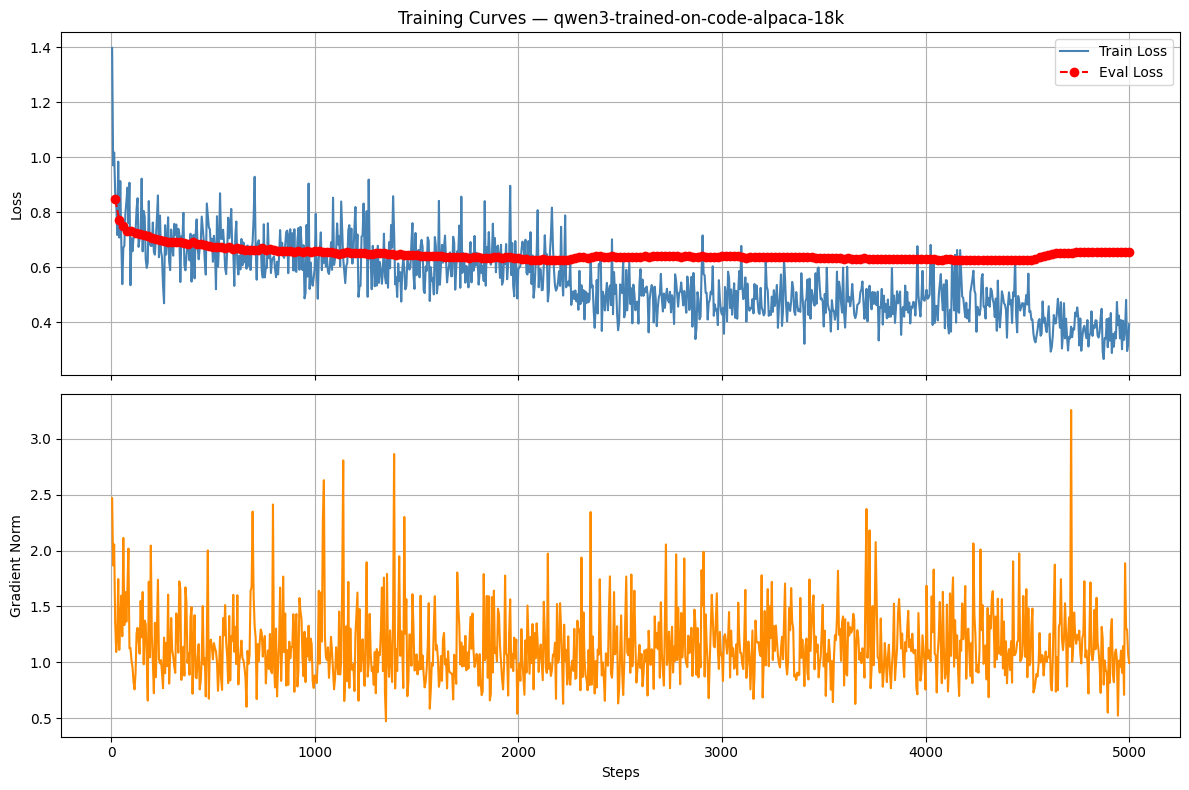

wandb: updating run metadata
wandb: 
wandb: Run history:
wandb:               eval/loss █▇▅▅▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▂▃▃
wandb:            eval/runtime ▁▂▂▂▆▆▆▆▅▅▆▅▆▆▆▇▆▆▇▆█▇▇▅▆▆▆▇▇▆▆▆▇▅▅▆▅▆▆▆
wandb: eval/samples_per_second ███▇█▂▃▂▂▂▂▁▃▄▃▃▄▃▄▃▄▃▃▂▂▂▁▁▃▃▄▄▂▂▃▂▃▄▂▄
wandb:   eval/steps_per_second █▇███▃▂▂▁▂▂▃▁▂▂▃▃▂▃▄▄▃▁▁▂▂▁▃▃▂▄▃▃▃▃▃▃▂▃▄
wandb:             train/epoch ▁▁▁▁▁▃▃▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇█████
wandb:       train/global_step ▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▆▆▆▆▆▆▇▇▇▇███
wandb:         train/grad_norm ▃▅▃▅▂▂▃▂▂▂▂▂▃▃▂█▃▂▄▂▁▁▄▂▃▂▅▃▂▄▂▄▂▄▂▃▂▃▂▁
wandb:     train/learning_rate █▇▇▇▇▇▇▆▆▆▆▆▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁
wandb:              train/loss ▅▄▆█▇▅▄▄▄▅▅▆▄▅▄▄▃▄▃▅▄▄▃▃▂▄▄▃▃▃▂▃▂▂▃▃▃▂▁▁
wandb: 
wandb: Run summary:
wandb:               eval/loss 0.65692
wandb:            eval/runtime 17.0509
wandb: eval/samples_per_second 29.324
wandb:   eval/steps_per_second 7.331
wandb:              total_flos 1.177743384576e+16
wandb:             train/epoch 2.21931
wandb:       train/global

README.md:   0%|          | 0.00/560 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/Srishtik/qwen3-trained-on-code-alpaca-18k


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

In [16]:
train_adapter(train_updated,test_updated,"qwen3-trained-on-code-alpaca-18k")